<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   objec

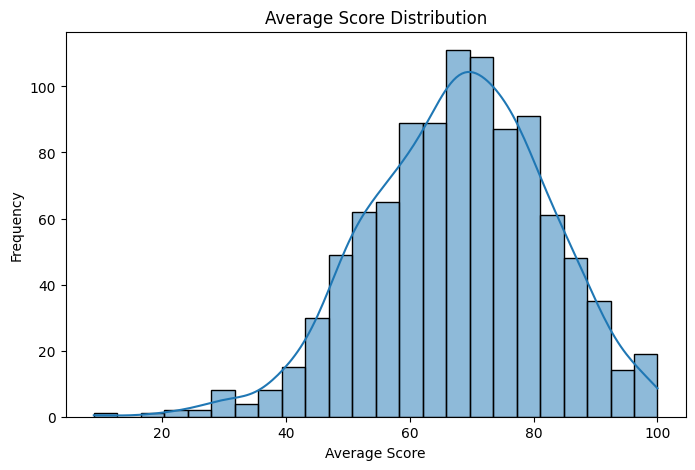

In [1]:
# ============================================================
# Student Performance Indicator
# ============================================================

# ------------------------------------------------------------
# Life cycle of Machine learning Project
#
# - Understanding the Problem Statement
# - Data Collection
# - Data Checks to perform
# - Exploratory data analysis
# - Data Pre-Processing
# - Model Training
# - Choose best model
# ------------------------------------------------------------

# ------------------------------------------------------------
# 1) Problem statement
#
# This project understands how the student's performance
# (test scores) is affected by other variables such as
# Gender, Ethnicity, Parental level of education,
# Lunch and Test preparation course.
# ------------------------------------------------------------

# ------------------------------------------------------------
# 2) Data Collection
#
# Dataset Source:
# https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
#
# The data consists of 8 columns and 1000 rows.
# ------------------------------------------------------------

# ------------------------------------------------------------
# 2.1 Import Data and Required Packages
# Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# For Jupyter Notebook plotting
# %matplotlib inline

# ------------------------------------------------------------
# Import the CSV Data as Pandas DataFrame
# ------------------------------------------------------------

df = pd.read_csv(r"C:/Users/chunc/Music/mlproject/notebook/StudentsPerformance.csv")

# ------------------------------------------------------------
# Show Top 5 Records
# ------------------------------------------------------------

df.head()

# ------------------------------------------------------------
# Shape of the dataset
# ------------------------------------------------------------

df.shape

# ------------------------------------------------------------
# 2.2 Dataset information
#
# - gender : sex of students -> (male/female)
# - race/ethnicity : ethnicity of students -> (Group A, B, C, D, E)
# - parental level of education : parents' final education
#   (bachelor's degree, some college, master's degree,
#    associate's degree, high school, some high school)
# - lunch : having lunch before test (standard or free/reduced)
# - test preparation course : completed or not completed
# - math score
# - reading score
# - writing score
# ------------------------------------------------------------

df.info()

# ------------------------------------------------------------
# 3) Data Checks to perform
#
# - Check Missing values
# - Check Duplicates
# - Check data type
# - Check number of unique values of each column
# - Check statistics of data set
# - Check various categories present in categorical columns
# ------------------------------------------------------------

# ------------------------------------------------------------
# 3.1 Check Missing values
# ------------------------------------------------------------

df.isna().sum()

# There are no missing values in the dataset

# ------------------------------------------------------------
# 3.2 Check Duplicates
# ------------------------------------------------------------

df.duplicated().sum()

# There are no duplicate values in the dataset

# ------------------------------------------------------------
# 3.3 Check data types
# ------------------------------------------------------------

df.info()

# ------------------------------------------------------------
# 3.4 Check number of unique values of each column
# ------------------------------------------------------------

df.nunique()

# ------------------------------------------------------------
# 3.5 Check statistics of data set
# ------------------------------------------------------------

df.describe()

# ------------------------------------------------------------
# Insight
#
# - Mean scores are close to each other (66–68)
# - Standard deviations are also close (14–15)
# - Minimum math score is 0
# - Minimum writing score is 10
# - Minimum reading score is 17
# ------------------------------------------------------------

# ------------------------------------------------------------
# 3.7 Exploring Data
# ------------------------------------------------------------

df.head()

# ------------------------------------------------------------
# Categories in categorical variables
# ------------------------------------------------------------

print("Categories in 'gender' variable:", df["gender"].unique())
print("Categories in 'race/ethnicity' variable:", df["race/ethnicity"].unique())
print("Categories in 'parental level of education' variable:",
      df["parental_level_of_education"].unique())
print("Categories in 'lunch' variable:", df["lunch"].unique())
print("Categories in 'test preparation course' variable:",
      df["test_preparation_course"].unique())

# ------------------------------------------------------------
# Define numerical & categorical columns
# ------------------------------------------------------------

numeric_features = [col for col in df.columns if df[col].dtype != "O"]
categorical_features = [col for col in df.columns if df[col].dtype == "O"]

print("We have {} numerical features : {}".format(len(numeric_features), numeric_features))
print("We have {} categorical features : {}".format(len(categorical_features), categorical_features))

# ------------------------------------------------------------
# 3.8 Adding columns for "Total Score" and "Average"
# ------------------------------------------------------------

df["total score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average"] = df["total score"] / 3

df.head()

# ------------------------------------------------------------
# Students performance insights
# ------------------------------------------------------------

reading_full = df[df["reading_score"] == 100]["average"].count()
writing_full = df[df["writing_score"] == 100]["average"].count()
math_full = df[df["math_score"] == 100]["average"].count()

print("Number of students with full marks in Maths:", math_full)
print("Number of students with full marks in Writing:", writing_full)
print("Number of students with full marks in Reading:", reading_full)

reading_less_20 = df[df["reading_score"] <= 20]["average"].count()
writing_less_20 = df[df["writing_score"] <= 20]["average"].count()
math_less_20 = df[df["math_score"] <= 20]["average"].count()

print("Number of students with less than 20 marks in Maths:", math_less_20)
print("Number of students with less than 20 marks in Writing:", writing_less_20)
print("Number of students with less than 20 marks in Reading:", reading_less_20)

# Insights:
# - Students performed worst in Maths
# - Best performance is in Reading

# ------------------------------------------------------------
# 4) Exploring Data (Visualization)
# 4.1 Visualize average score distribution
# - Histogram
# - Kernel Distribution Function (KDE)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.histplot(df["average"], kde=True)
plt.title("Average Score Distribution")
plt.xlabel("Average Score")
plt.ylabel("Frequency")
plt.show()
